<a href="https://colab.research.google.com/github/Arif0000/GFG-21-Days-Live-class-task/blob/main/Task_6_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
!git clone "https://github.com/HarshvardhanSingh-13/Datasets"
df = pd.read_csv('/content/Datasets/Airline Timeseries/airline_passenger_timeseries.csv')
df.head(5)

Cloning into 'Datasets'...
remote: Enumerating objects: 347, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 347 (delta 25), reused 0 (delta 0), pack-reused 242 (from 1)
Receiving objects: 100% (347/347), 302.89 MiB | 15.19 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (245/245), done.


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


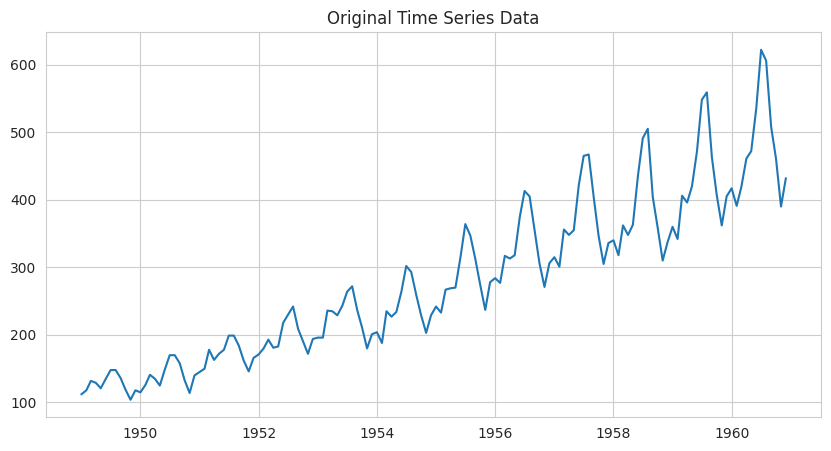

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
ADF Statistic after transformation: -2.717130598388114
p-value after transformation: 0.07112054815086184


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 124.313
Date:                Sun, 01 Mar 2026   AIC                           -242.626
Time:                        10:55:59   BIC                           -233.738
Sample:                    01-01-1949   HQIC                          -239.014
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5773      0.164     -3.516      0.000      -0.899      -0.256
ma.L1          0.8478      0.098      8.687      0.000       0.657       1.039
sigma2         0.0103      0.002      5.991      0.0

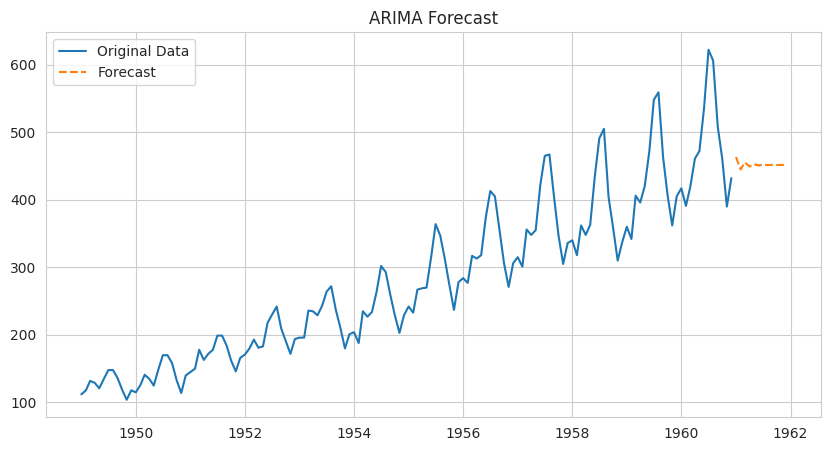

In [3]:
df['Month'] = pd.to_datetime(df['Month'])

df.set_index('Month', inplace=True)



plt.figure(figsize=(10,5))
plt.plot(df['Passengers'])
plt.title("Original Time Series Data")
plt.show()



result = adfuller(df['Passengers'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

df_log = np.log(df['Passengers'])


df_diff = df_log.diff().dropna()

result2 = adfuller(df_diff)

print("ADF Statistic after transformation:", result2[0])
print("p-value after transformation:", result2[1])



model = ARIMA(df_log, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())



forecast = model_fit.forecast(steps=12)



forecast = np.exp(forecast)

print("Future Predictions:")
print(forecast)



plt.figure(figsize=(10,5))
plt.plot(df['Passengers'], label="Original Data")
plt.plot(forecast, label="Forecast", linestyle="dashed")
plt.legend()
plt.title("ARIMA Forecast")
plt.show()